## Gradient descent

Gradient descent is a common method used to find minimum of a function. 

Below is a simple demonstration of using gradient descent method to find the minimum of a scalar function. Example function,

$$f(x) = x^2 + x + 3$$

Its derivative is 

$$f'(x) = 2x+1$$

In [3]:
import sympy as sp

# symbol
x = sp.symbols('x')

# example toy problem
a = sp.Integer(2)
b = sp.Integer(1)
c = sp.Integer(3)

# function
f = a/2 * x**2 + b*x + c

# gradient
f_x = sp.diff(f, x)



* Start with an initial guess $x_0$. At $x_0$, the gradient is $f'(x_0)$. 

* We march with a step of $\alpha$.

* The next position will be $x_1 = x_0 - \alpha f'(x_0)$.

* Then, we can march from $x_1$ to the next position, such that $x_2 = x_1 - \alpha f'(x_1)$. Each march is moving toward the minimum.

* Repeating this procedure and eventually, we will arrive the minimum. 



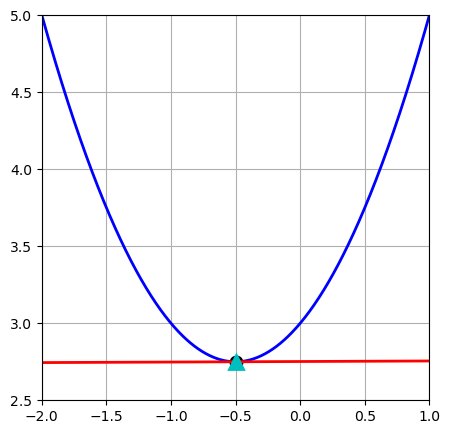

<Figure size 500x500 with 0 Axes>

In [21]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from IPython.display import display, clear_output
import time

# initial guess
x0 = 0.9

# stepping size
alp = 0.1


# numeric callables for fast plotting
f_fn = sp.lambdify(x, f, "numpy")

# plotting domain
X = np.linspace(-2, 1, 800)

# set up a single figure and reuse it
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_xlim(-2.0, 1.0)

Yf = f_fn(X)

for iter in range(0, 31):
    # gradient and value at current x0
    grd  = float(f_x.subs({x: x0}))
    val0 = float(f.subs({x: x0}))

    # tangent line: y = grd*(x - x0) + val0
    Ytan = grd * (X - x0) + val0  

    # ----- visualization ----- 
    plt.plot(X, Yf, 'b', lw=2, label='φ(x)')
    plt.plot([x0], [val0], 'ko', ms=8, mec='k', mfc='none', mew=2)  
    plt.plot(X, Ytan, 'r', lw=2, label='tangent at x₀')


    # ----- gradient-descent update -----
    x1   = x0 - alp * grd
    val1 = grd * (x1 - x0) + val0  # value on the tangent line at the stepped x  
    
    # time.sleep(0.5)   
    plt.plot([x1], [val1], 'c^', ms=10, mew=2)
    plt.grid(True)
    plt.axis([-2, 1, 2.5, 5])


   
    # Animaiton part (dosn't change)
    clear_output(wait=True) # Clear output for dynamic display
    display(fig)            # Reset display
    fig.clear()             # Prevent overlapping and layered plots
    time.sleep(0.5)         # Sleep for half a second to slow down the animation
        
    
    # advance
    x0 = float(x1)



---

The analogy of this gradient descent is the Allen-Cahn type of phase fied model. For example,

$$\frac{\partial \phi}{\partial t} = -L \frac{\delta F(\phi)}{\delta \phi} ~\Longrightarrow~\phi^{(n+1)} = \phi^{(n)} - \Delta t L \frac{\delta F(\phi)}{\delta \phi}^{(n)}.$$

Note that $\phi(x)$ is a function with spatial variable $x$, and $F[\phi(x)]$ is functional of function $\phi(x)$. The Gateaux derivative is the derivative of $F$ with repsect to $\phi$. Thus, the process will eventually leads to the function of $\phi(x)$ that minimize the total energy, $F[\phi(x)]$, of the system.